Imports

In [ ]:
!pip install datasets

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split

Dataset


*   Load directly from HuggingFace

*   Convert to Panads




In [ ]:
from datasets import load_dataset

dataset = load_dataset("Allanatrix/CFD")

df = dataset["train"].to_pandas()

print(df.head())
print(df.columns)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Flow.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

          t         x         y         u         v         p      dudx  \
0  0.022222  0.368421  0.088889  0.393358  0.001115 -2.953893  0.152946   
1  0.100000  0.315789  0.077778  0.694818 -0.001654 -2.531341 -0.100485   
2  0.033333  0.263158  0.022222  0.704109 -0.000018 -2.103342  0.178065   
3  0.100000  0.052632  0.044444  1.002908 -0.001317 -0.410112 -0.151426   
4  0.011111  0.789474  0.100000 -0.010775 -0.002226 -6.315435  0.000000   

        dudy      dvdx      dvdy      dudt      dvdt flow_type  sample_id  
0 -31.138013  0.030149 -0.082668 -0.820783  0.018075   laminar         63  
1 -21.879110 -0.007235  0.056004 -0.027166 -0.151602   laminar         77  
2  23.040452  0.022634  0.011209  0.343724 -0.002956   laminar         67  
3   4.189388 -0.037293 -0.000843  1.339783 -0.056770   laminar         52  
4   0.000000  0.000000  0.000000  0.179054  0.061017   laminar         62  
Index(['t', 'x', 'y', 'u', 'v', 'p', 'dudx', 'dudy', 'dvdx', 'dvdy', 'dudt',
       'dvdt', '

Convert to Panads

In [ ]:
df = dataset['train'].to_pandas()

In [ ]:
print(df.head())
print(df.columns)

          t         x         y         u         v         p      dudx  \
0  0.022222  0.368421  0.088889  0.393358  0.001115 -2.953893  0.152946   
1  0.100000  0.315789  0.077778  0.694818 -0.001654 -2.531341 -0.100485   
2  0.033333  0.263158  0.022222  0.704109 -0.000018 -2.103342  0.178065   
3  0.100000  0.052632  0.044444  1.002908 -0.001317 -0.410112 -0.151426   
4  0.011111  0.789474  0.100000 -0.010775 -0.002226 -6.315435  0.000000   

        dudy      dvdx      dvdy      dudt      dvdt flow_type  sample_id  
0 -31.138013  0.030149 -0.082668 -0.820783  0.018075   laminar         63  
1 -21.879110 -0.007235  0.056004 -0.027166 -0.151602   laminar         77  
2  23.040452  0.022634  0.011209  0.343724 -0.002956   laminar         67  
3   4.189388 -0.037293 -0.000843  1.339783 -0.056770   laminar         52  
4   0.000000  0.000000  0.000000  0.179054  0.061017   laminar         62  
Index(['t', 'x', 'y', 'u', 'v', 'p', 'dudx', 'dudy', 'dvdx', 'dvdy', 'dudt',
       'dvdt', '

Filter Laminar Flow

In [ ]:
df = df[df["flow_type"] == "laminar"]
print("Shape after filtering:", df.shape)

Shape after filtering: (5000, 14)


**Select Required Columns**

We will predict:

*   List item
*   List item


*  u
*  v

from:
*   x
*   y
*   t


In [ ]:
inputs = df[["x", "y", "t"]].values
outputs = df[["u", "v"]].values

train/val/test

In [ ]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    inputs, outputs, test_size=0.8, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(1000, 3) (2000, 3) (2000, 3)


Data Normalization

In [ ]:
x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0)

y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0)

def normalize(x, mean, std):
    return (x - mean) / std

X_train = normalize(X_train, x_mean, x_std)
X_val   = normalize(X_val, x_mean, x_std)
X_test  = normalize(X_test, x_mean, x_std)

Y_train = normalize(Y_train, y_mean, y_std)
Y_val   = normalize(Y_val, y_mean, y_std)
Y_test  = normalize(Y_test, y_mean, y_std)

Convert to Tensors

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train, dtype=torch.float32, requires_grad=True)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

DataLoader

In [ ]:
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

PINN Model

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()

Physics Loss using Continuity Equation

∂u/∂x+∂v/∂y=0

In [ ]:
def physics_loss(model, X):
    pred = model(X)

    u = pred[:, 0:1]
    v = pred[:, 1:2]

    grads_u = torch.autograd.grad(
        u, X,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    grads_v = torch.autograd.grad(
        v, X,
        grad_outputs=torch.ones_like(v),
        create_graph=True
    )[0]

    dudx = grads_u[:, 0:1]
    dvdy = grads_v[:, 1:2]

    continuity = dudx + dvdy

    return torch.mean(continuity**2)

Training Loop (with Validation)

In [ ]:
num_epochs = 2000
lambda_phy = 0.1

train_history = []
val_history = []

for epoch in range(num_epochs):

    model.train()
    train_loss_epoch = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        pred = model(batch_X)

        data_loss = mse_loss(pred, batch_Y)
        phy_loss = physics_loss(model, batch_X)

        loss = data_loss + lambda_phy * phy_loss

        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()

    # ---------- validation ----------
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val.to(device))
        val_loss = mse_loss(val_pred, Y_val.to(device))

    train_history.append(train_loss_epoch)
    val_history.append(val_loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Train Loss: {train_loss_epoch:.6f} | Val Loss: {val_loss.item():.6f}")

Epoch 0 | Train Loss: 3.996477 | Val Loss: 1.017674
Epoch 100 | Train Loss: 1.991579 | Val Loss: 0.562713
Epoch 200 | Train Loss: 1.971180 | Val Loss: 0.566103
Epoch 300 | Train Loss: 1.933521 | Val Loss: 0.569619
Epoch 400 | Train Loss: 1.915053 | Val Loss: 0.575106
Epoch 500 | Train Loss: 1.886727 | Val Loss: 0.582734
Epoch 600 | Train Loss: 1.856990 | Val Loss: 0.595598
Epoch 700 | Train Loss: 1.835511 | Val Loss: 0.598860
Epoch 800 | Train Loss: 1.829769 | Val Loss: 0.601722
Epoch 900 | Train Loss: 1.815857 | Val Loss: 0.608703
Epoch 1000 | Train Loss: 1.800287 | Val Loss: 0.605897
Epoch 1100 | Train Loss: 1.780535 | Val Loss: 0.611877
Epoch 1200 | Train Loss: 1.765072 | Val Loss: 0.616952
Epoch 1300 | Train Loss: 1.748548 | Val Loss: 0.627653
Epoch 1400 | Train Loss: 1.717787 | Val Loss: 0.630867
Epoch 1500 | Train Loss: 1.683122 | Val Loss: 0.638711
Epoch 1600 | Train Loss: 1.665743 | Val Loss: 0.645482
Epoch 1700 | Train Loss: 1.644677 | Val Loss: 0.649729
Epoch 1800 | Train Los

Loss Plot

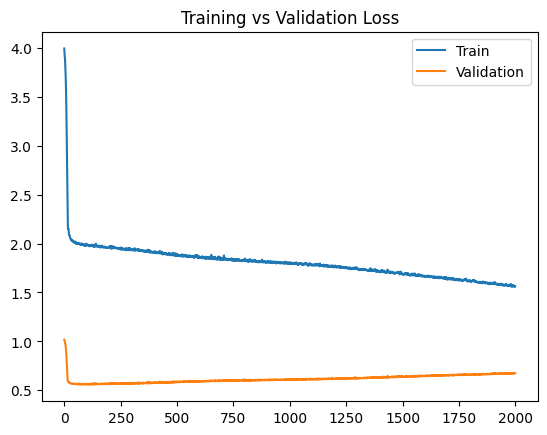

In [ ]:
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Full Field Prediction

In [ ]:
X_all = normalize(inputs, x_mean, x_std)
X_all = torch.tensor(X_all, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    pred_all = model(X_all).cpu().numpy()

# denormalize
pred_all = pred_all * y_std + y_mean
true_all = outputs

Test Evaluation

In [ ]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test.to(device)).cpu().numpy()

test_pred = test_pred * y_std + y_mean
Y_test_np = Y_test.numpy() * y_std + y_mean

mse = np.mean((test_pred - Y_test_np)**2)
print("Test MSE:", mse)

rel_l2 = np.linalg.norm(test_pred - Y_test_np) / np.linalg.norm(Y_test_np)
print("Relative L2 Error:", rel_l2)

Test MSE: 0.0014568820307226977
Relative L2 Error: 0.07758894335041155


Error Maps

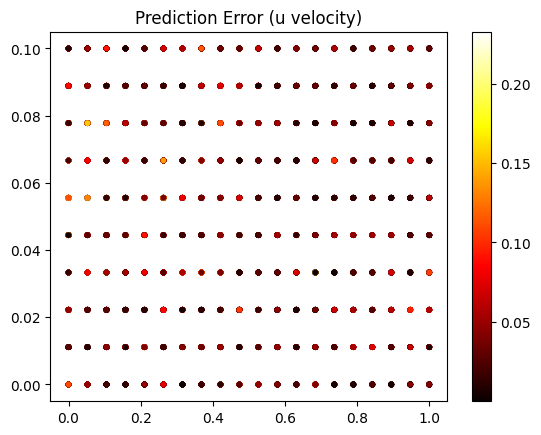

In [ ]:
error = np.abs(true_all[:,0] - pred_all[:,0])

plt.scatter(df["x"], df["y"], c=error, cmap="hot", s=10)
plt.colorbar()
plt.title("Prediction Error (u velocity)")
plt.show()

Ground Truth vs Prediction

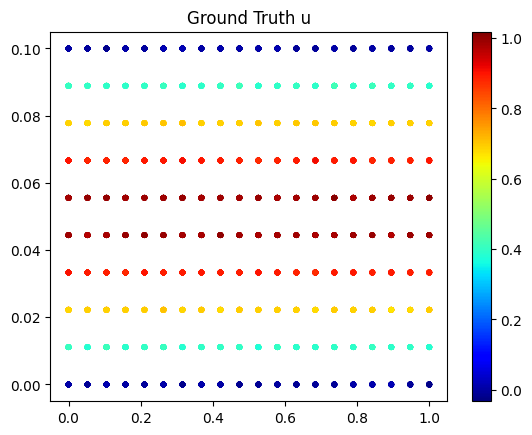

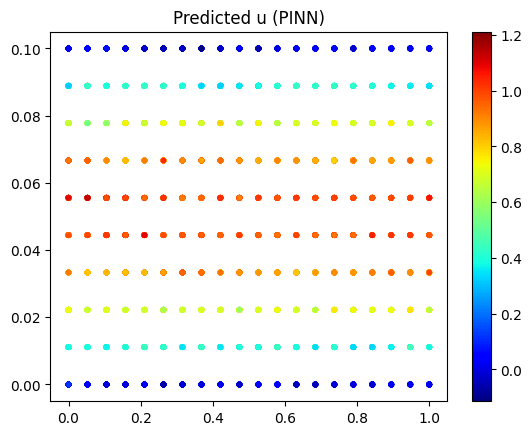

In [ ]:
plt.figure()
plt.scatter(df["x"], df["y"], c=true_all[:,0], cmap="jet", s=10)
plt.title("Ground Truth u")
plt.colorbar()
plt.show()

plt.figure()
plt.scatter(df["x"], df["y"], c=pred_all[:,0], cmap="jet", s=10)
plt.title("Predicted u (PINN)")
plt.colorbar()
plt.show()

Vector Field Plot

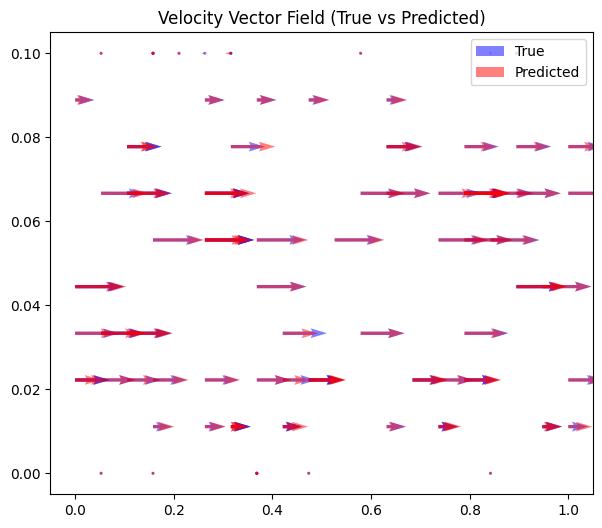

In [ ]:
plt.figure(figsize=(7,6))

plt.quiver(
    df["x"][::50],
    df["y"][::50],
    true_all[:,0][::50],
    true_all[:,1][::50],
    color="blue",
    alpha=0.5,
    label="True"
)

plt.quiver(
    df["x"][::50],
    df["y"][::50],
    pred_all[:,0][::50],
    pred_all[:,1][::50],
    color="red",
    alpha=0.5,
    label="Predicted"
)

plt.title("Velocity Vector Field (True vs Predicted)")
plt.legend()
plt.show()

Streamline Plot (BEST CFD visualization)

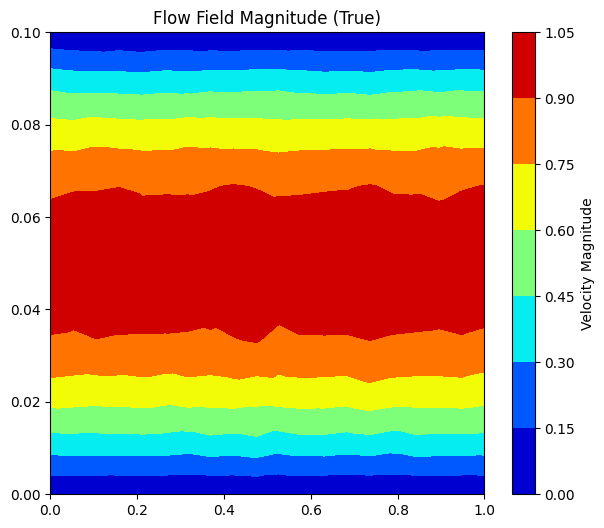

In [ ]:
plt.figure(figsize=(7,6))

plt.tricontourf(
    df["x"],
    df["y"],
    np.sqrt(true_all[:,0]**2 + true_all[:,1]**2),
    cmap="jet"
)

plt.colorbar(label="Velocity Magnitude")
plt.title("Flow Field Magnitude (True)")
plt.show()

Residual Physics Error Map (PINN-specific)

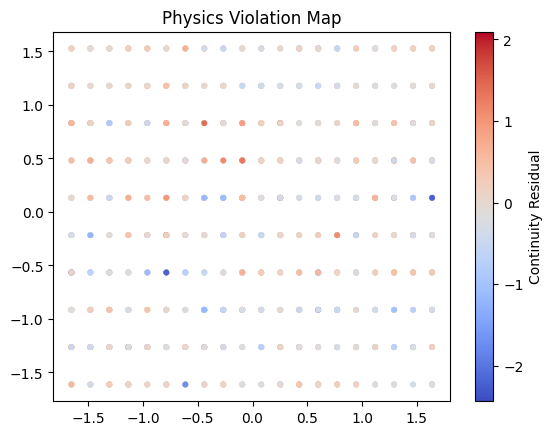

In [ ]:
model.eval()

X_phys = X_test.to(device).clone().detach().requires_grad_(True)

pred = model(X_phys)

u = pred[:,0:1]
v = pred[:,1:2]

du = torch.autograd.grad(u, X_phys, torch.ones_like(u), create_graph=True)[0]
dv = torch.autograd.grad(v, X_phys, torch.ones_like(v), create_graph=True)[0]

div = du[:,0] + dv[:,1]

div = div.detach().cpu().numpy()

plt.scatter(X_test[:,0], X_test[:,1], c=div, cmap="coolwarm", s=10)
plt.colorbar(label="Continuity Residual")
plt.title("Physics Violation Map")
plt.show()

Error vs Magnitude Plot

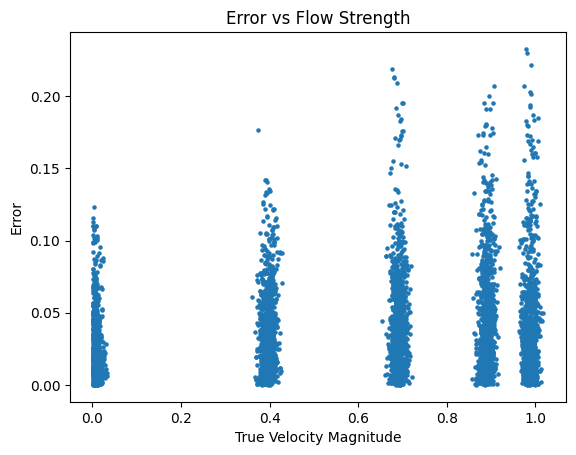

In [ ]:
vel_mag_true = np.sqrt(true_all[:,0]**2 + true_all[:,1]**2)
vel_mag_pred = np.sqrt(pred_all[:,0]**2 + pred_all[:,1]**2)

error = np.abs(vel_mag_true - vel_mag_pred)

plt.scatter(vel_mag_true, error, s=5)
plt.xlabel("True Velocity Magnitude")
plt.ylabel("Error")
plt.title("Error vs Flow Strength")
plt.show()

Parity Plot

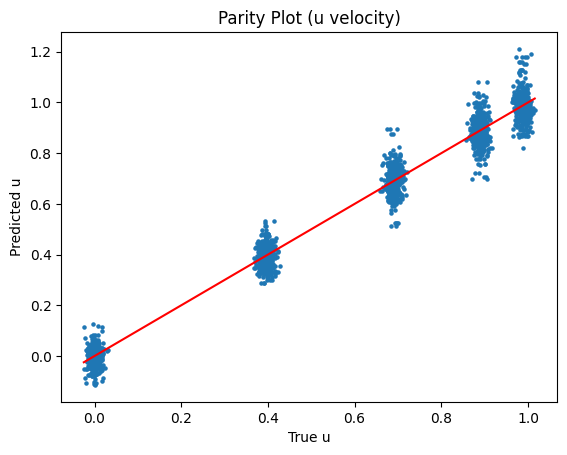

In [ ]:
plt.scatter(Y_test_np[:,0], test_pred[:,0], s=5)
plt.plot([Y_test_np[:,0].min(), Y_test_np[:,0].max()],
         [Y_test_np[:,0].min(), Y_test_np[:,0].max()],
         'r')

plt.xlabel("True u")
plt.ylabel("Predicted u")
plt.title("Parity Plot (u velocity)")
plt.show()

Time Slice Visualization

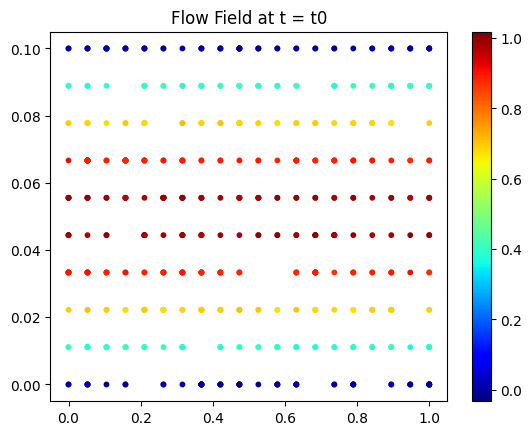

In [ ]:
t0_mask = df["t"] == df["t"].iloc[0]

plt.scatter(
    df["x"][t0_mask],
    df["y"][t0_mask],
    c=true_all[:,0][t0_mask],
    cmap="jet",
    s=10
)

plt.title("Flow Field at t = t0")
plt.colorbar()
plt.show()